In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
X

array([[-1.56030681,  5.17933063],
       [ 3.12314877, -4.3250763 ],
       [ 2.12159964, -1.76558219],
       ...,
       [-1.57386527,  5.91505486],
       [-2.47759138,  4.93221243],
       [ 3.03299145, -1.88008616]], shape=(1000, 2))

In [4]:
y

array([0, 1, 2, 1, 1, 0, 1, 2, 2, 0, 2, 0, 0, 1, 1, 0, 2, 2, 2, 2, 2, 0,
       1, 1, 2, 1, 0, 1, 2, 0, 1, 1, 1, 1, 0, 2, 1, 0, 2, 0, 1, 2, 0, 2,
       1, 2, 1, 2, 2, 2, 2, 1, 2, 0, 0, 0, 2, 0, 1, 2, 1, 0, 0, 0, 0, 2,
       1, 0, 2, 2, 1, 0, 2, 1, 2, 2, 0, 0, 2, 1, 0, 2, 0, 2, 2, 0, 0, 0,
       1, 1, 0, 1, 0, 2, 1, 2, 2, 1, 1, 0, 1, 0, 1, 2, 0, 2, 2, 0, 0, 0,
       0, 1, 2, 1, 2, 2, 0, 0, 2, 2, 1, 1, 1, 2, 0, 1, 0, 1, 0, 1, 0, 0,
       2, 2, 1, 0, 0, 2, 0, 2, 1, 2, 0, 0, 2, 1, 1, 1, 2, 2, 0, 1, 2, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 2, 2, 0, 1, 2, 0, 0, 1, 2, 2, 1, 2, 2,
       1, 2, 1, 0, 1, 1, 2, 0, 0, 1, 2, 2, 1, 2, 1, 2, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 2, 1, 2, 2, 0, 2, 1, 2, 2, 0, 0, 0, 1, 1, 1, 2,
       0, 1, 1, 2, 2, 1, 1, 0, 2, 1, 0, 0, 1, 0, 0, 0, 0, 1, 2, 1, 1, 2,
       1, 1, 0, 0, 0, 2, 2, 1, 2, 2, 2, 2, 2, 0, 2, 1, 0, 2, 2, 2, 1, 1,
       2, 0, 0, 2, 0, 0, 1, 0, 0, 1, 2, 0, 0, 0, 2, 0, 1, 0, 2, 1, 2, 0,
       0, 0, 1, 2, 0, 1, 2, 2, 2, 2, 2, 0, 1, 1, 1,

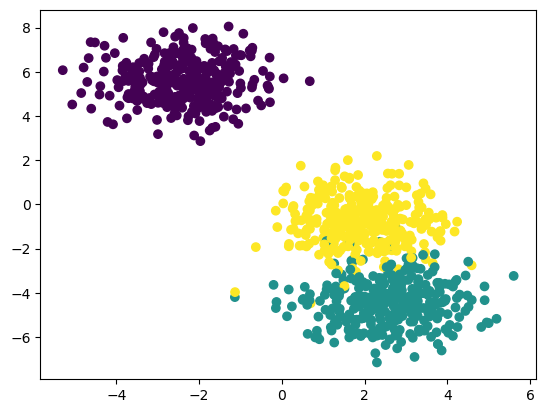

In [7]:
plt.scatter(X[:,0], X[:,1],c=y)

In [8]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler

In [9]:
scaler=StandardScaler()

In [10]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [13]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [15]:
from sklearn.cluster import KMeans

In [16]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

C:\Users\Thinkpad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Thinkpad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Thinkpad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Thinkpad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

In [17]:
wcss

[1339.9999999999995,
 239.0176718236692,
 147.6729769967689,
 121.64500360410703,
 95.79024169104586,
 77.6834826954835,
 70.89333642880763,
 65.5527516987355,
 58.31109397595922,
 52.12022481434516]

## Elbow Curve

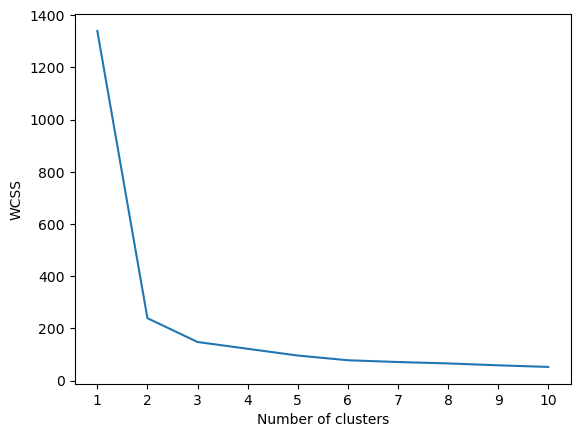

In [20]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()          

In [21]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [22]:
kmeans.fit_predict(X_train_scaled)

C:\Users\Thinkpad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([0, 1, 2, 2, 0, 0, 0, 2, 0, 2, 2, 1, 1, 2, 1, 2, 0, 2, 0, 0, 2, 1,
       2, 1, 2, 0, 2, 2, 0, 1, 0, 1, 0, 2, 1, 1, 1, 2, 2, 2, 0, 2, 2, 2,
       2, 0, 1, 2, 1, 1, 1, 2, 1, 0, 0, 2, 2, 1, 1, 2, 2, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 2, 2, 0, 0, 2, 0, 2, 1, 2, 2, 2, 2, 2, 0, 2, 2,
       2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 0, 0,
       1, 0, 1, 0, 2, 0, 0, 2, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 2, 1, 1,
       1, 0, 0, 0, 1, 1, 2, 2, 2, 0, 0, 2, 2, 1, 1, 0, 2, 0, 2, 2, 0, 0,
       1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 2, 2, 1, 1, 0, 0, 2, 1, 1, 1, 1,
       2, 1, 1, 0, 2, 2, 0, 0, 2, 1, 2, 0, 0, 1, 1, 2, 0, 1, 0, 0, 1, 0,
       1, 1, 2, 1, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2, 2, 0,
       0, 2, 2, 0, 0, 2, 1, 0, 2, 2, 0, 1, 1, 0, 2, 2, 0, 0, 1, 1, 1, 0,
       2, 1, 2, 0, 0, 1, 0, 2, 1, 1, 0, 1, 2, 0, 1, 0, 2, 1, 0, 2, 0, 1,
       1, 2, 0, 0, 1, 2, 1, 2, 1, 0, 2, 2, 1, 1, 0, 2, 2, 2, 1, 2, 1, 1,
       0, 1, 2, 1, 0, 2, 0, 1, 1, 0, 1, 2, 1, 2, 1,

In [23]:
y_predict = kmeans.predict(X_test_scaled)

In [24]:
y_predict

array([0, 1, 1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 1, 1, 1, 1, 2, 1, 1, 0, 1, 1,
       1, 0, 2, 0, 0, 0, 1, 0, 0, 1, 2, 2, 2, 0, 2, 0, 0, 1, 2, 1, 1, 2,
       2, 0, 0, 2, 0, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 1, 1, 0, 2, 1, 0, 2,
       1, 2, 2, 2, 0, 2, 1, 0, 1, 1, 0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 1,
       2, 0, 0, 1, 2, 2, 1, 0, 2, 2, 0, 0, 1, 0, 2, 1, 1, 1, 1, 1, 0, 0,
       2, 2, 0, 1, 0, 1, 0, 2, 1, 1, 0, 1, 2, 1, 2, 0, 0, 0, 0, 0, 0, 2,
       0, 2, 1, 0, 2, 0, 2, 1, 2, 1, 1, 0, 1, 1, 0, 0, 2, 1, 2, 0, 2, 0,
       2, 2, 1, 2, 2, 0, 1, 0, 2, 1, 0, 2, 2, 0, 2, 1, 2, 0, 0, 1, 2, 1,
       1, 1, 2, 1, 0, 2, 0, 2, 1, 1, 0, 2, 2, 2, 0, 1, 1, 2, 0, 2, 0, 0,
       2, 1, 0, 0, 1, 1, 2, 2, 0, 0, 1, 0, 1, 1, 2, 1, 0, 0, 2, 2, 1, 0,
       1, 2, 1, 1, 0, 1, 1, 0, 2, 0, 0, 2, 2, 1, 2, 2, 0, 1, 2, 1, 2, 1,
       1, 2, 2, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 2, 1, 1, 1, 0, 2, 2, 2, 0,
       0, 2, 2, 1, 0, 1, 1, 1, 2, 1, 1, 0, 2, 2, 1, 1, 0, 0, 2, 0, 1, 1,
       2, 2, 0, 2, 0, 0, 1, 0, 2, 0, 0, 1, 1, 0, 2,

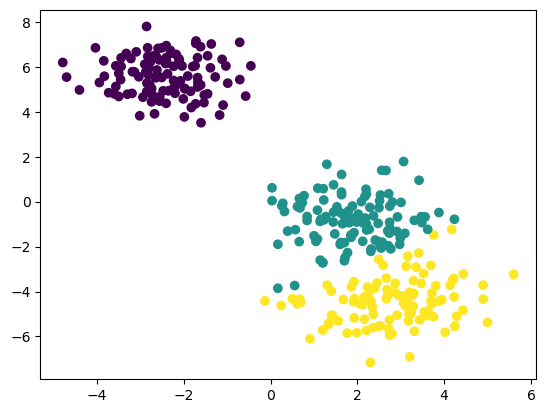

In [26]:
plt.scatter(X_test[:,0], X_test[:,1],c=y_predict)

## Validating the k value
     kneelocator
     Silhoutee scoring

### kneelocator

In [29]:
!pip install kneed --index-url https://pypi.org/simple/

Looking in indexes: https://pypi.org/simple/


In [30]:
from kneed import KneeLocator

In [31]:
kl=KneeLocator(range(1,11),wcss, curve="convex", direction="decreasing")

In [34]:
kl.elbow

np.int64(2)

### Silhoute Scoring

In [35]:
from sklearn.metrics import silhouette_score

In [36]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

C:\Users\Thinkpad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Thinkpad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Thinkpad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Thinkpad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

In [37]:
silhouette_coefficients

[0.722516184833004,
 0.5443710758107151,
 0.5091398897218737,
 0.4896748126887779,
 0.38710207747486025,
 0.3645274884503352,
 0.338338861414006,
 0.33669099357020305,
 0.33517133026573087]

Text(0, 0.5, 'Silhoutte Coeffecient')

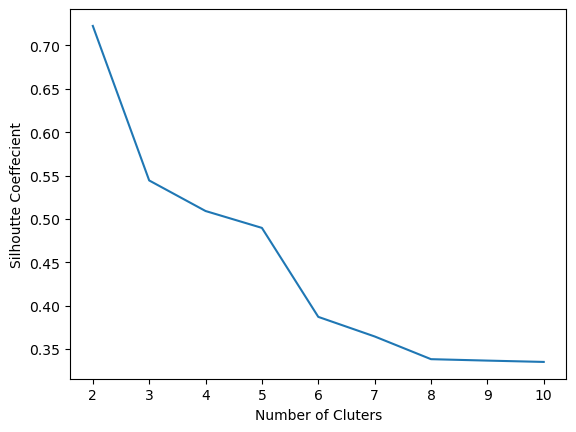

In [38]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")